<a href="https://colab.research.google.com/github/maddygoodro/MIS433/blob/main/in_class_5_27_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [1]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [2]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [3]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [4]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [5]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [6]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [7]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [8]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


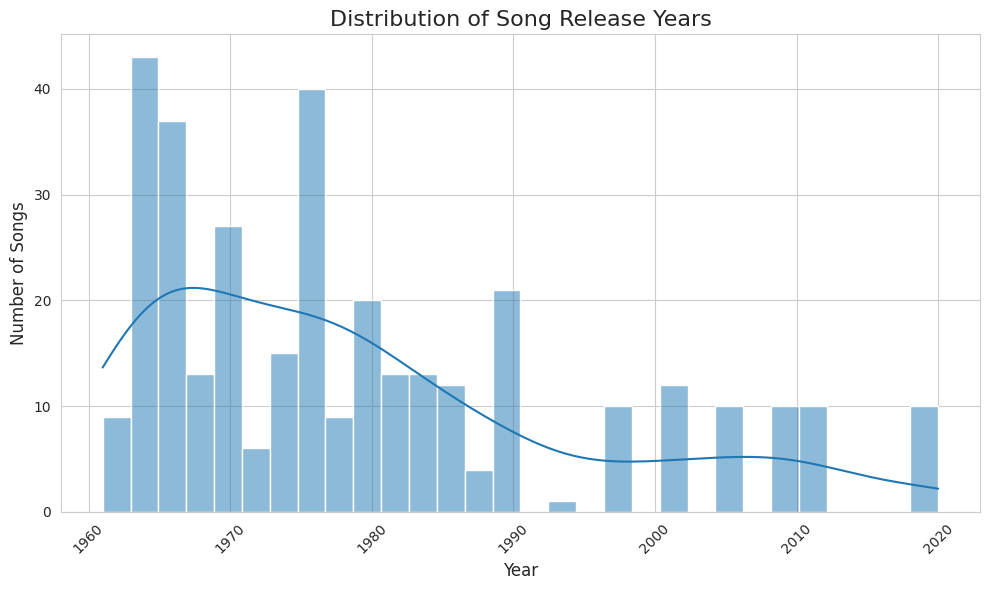

In [9]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [10]:
 !pip install scikit-learn

### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [12]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [13]:
# Size of the vocabulary
len(vocabulary)

7326

In [14]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [15]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [16]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_13676/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


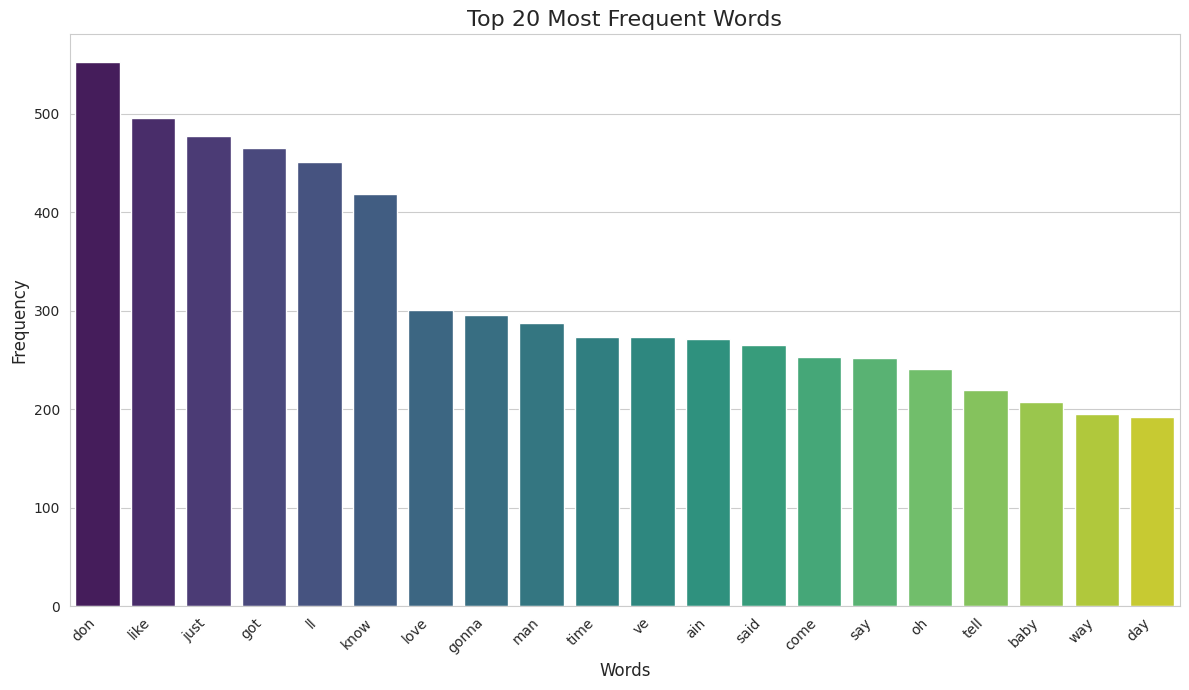

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [19]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


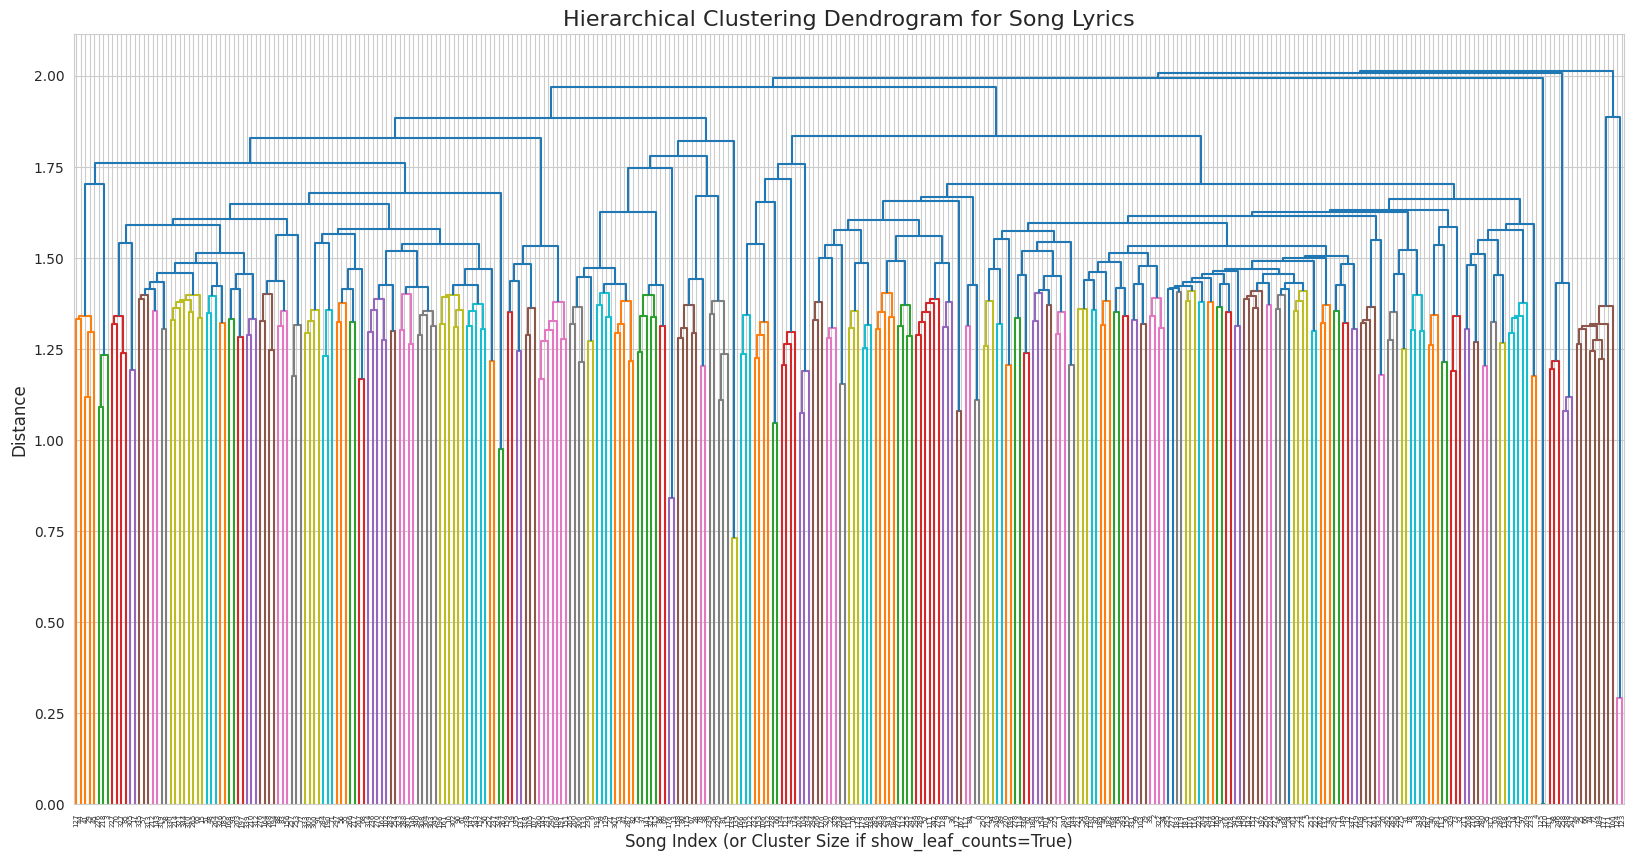

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [21]:
# Install wordcloud package
!pip install --upgrade wordcloud

In [22]:
# You may need to run this too.
!pip install --upgrade Pillow

  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


Found existing installation: pillow 12.2.0
Uninstalling pillow-12.2.0:
  Successfully uninstalled pillow-12.2.0
Found existing installation: wordcloud 1.9.6
Uninstalling wordcloud-1.9.6:
  Successfully uninstalled wordcloud-1.9.6
  Using cached pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
Using cached pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
  Using cached wordcloud-1.9.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (3.4 kB)
Using cached wordcloud-1.9.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (554 kB)


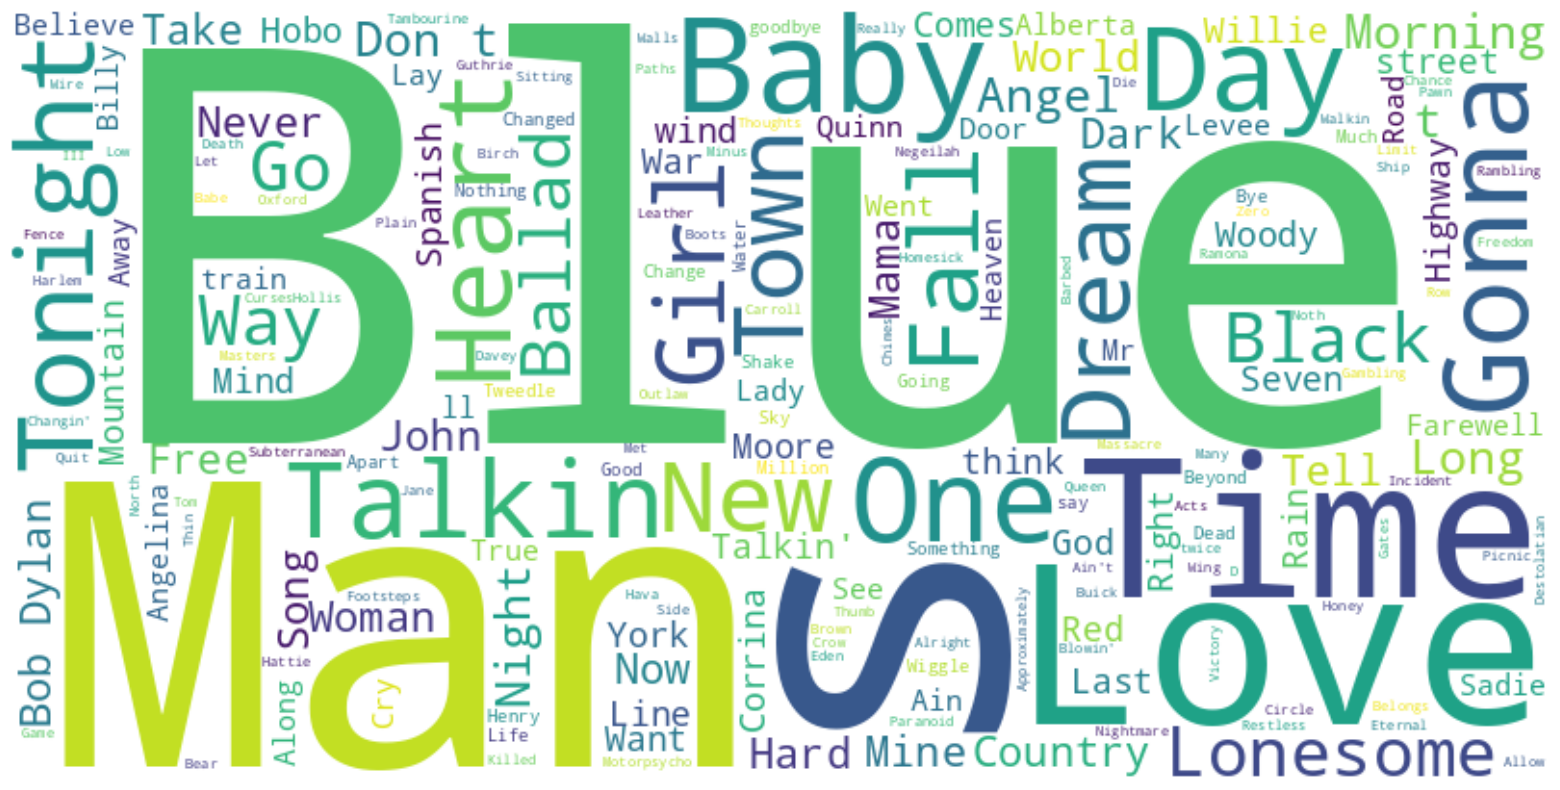

In [23]:
!pip uninstall -y Pillow wordcloud
!pip install Pillow==11.3.0
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Reload the df DataFrame as it might have been cleared
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [24]:
# Install TextBlob
!pip install textblob

In [25]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [27]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd # Import pandas if not already imported

# Ensure the 'decade' column is present before grouping
df['decade'] = (df['release_year'] // 10) * 10

# Group the DataFrame by 'decade'
decades = df.groupby('decade')

for decade, decade_df in decades:
    print(f"\n--- Top 10 Frequent Words for the {decade}s ---")

    # Combine all lyrics for the current decade into a single string
    decade_lyrics = " ".join(decade_df['lyrics'].dropna().tolist())

    # Initialize CountVectorizer for this decade
    # Remove common 'stop words' (e.g., 'the', 'a', 'is')
    # You might want to add more custom stop words if needed, or experiment with min_df/max_df
    vectorizer = CountVectorizer(stop_words='english')

    if decade_lyrics: # Only process if there are lyrics for the decade
        X = vectorizer.fit_transform([decade_lyrics])

        # Sum up the counts of each word (only one document per decade)
        word_counts = np.sum(X.toarray(), axis=0)

        # Get feature names (words)
        feature_words = vectorizer.get_feature_names_out()

        # Combine counts and words into a dictionary
        word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

        # Sort the dictionary by counts in descending order
        sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

        # Print the top 10 most frequent words
        top_10_words = sorted_word_count[:10]
        for word, count in top_10_words:
            print(f"  {word}: {count}")
    else:
        print("  No lyrics available for this decade.")


--- Top 10 Frequent Words for the 1960s ---
  just: 182
  don: 152
  like: 142
  ll: 138
  got: 135
  ain: 127
  know: 126
  said: 103
  come: 88
  man: 84

--- Top 10 Frequent Words for the 1970s ---
  like: 146
  don: 140
  gonna: 125
  just: 113
  said: 98
  know: 94
  ll: 91
  oh: 90
  time: 89
  got: 85

--- Top 10 Frequent Words for the 1980s ---
  don: 135
  got: 110
  know: 105
  like: 97
  just: 96
  love: 87
  man: 67
  time: 64
  ll: 60
  baby: 59

--- Top 10 Frequent Words for the 1990s ---
  wiggle: 55
  like: 42
  don: 36
  got: 31
  god: 28
  know: 27
  til: 27
  just: 26
  knows: 22
  gonna: 21

--- Top 10 Frequent Words for the 2000s ---
  got: 77
  don: 57
  ll: 52
  gonna: 51
  just: 44
  know: 44
  day: 41
  say: 41
  ain: 39
  good: 39

--- Top 10 Frequent Words for the 2010s ---
  ll: 44
  long: 32
  blowin: 22
  work: 22
  way: 20
  like: 18
  day: 16
  heart: 16
  town: 14
  light: 13

--- Top 10 Frequent Words for the 2020s ---
  play: 70
  ll: 47
  key: 27
  

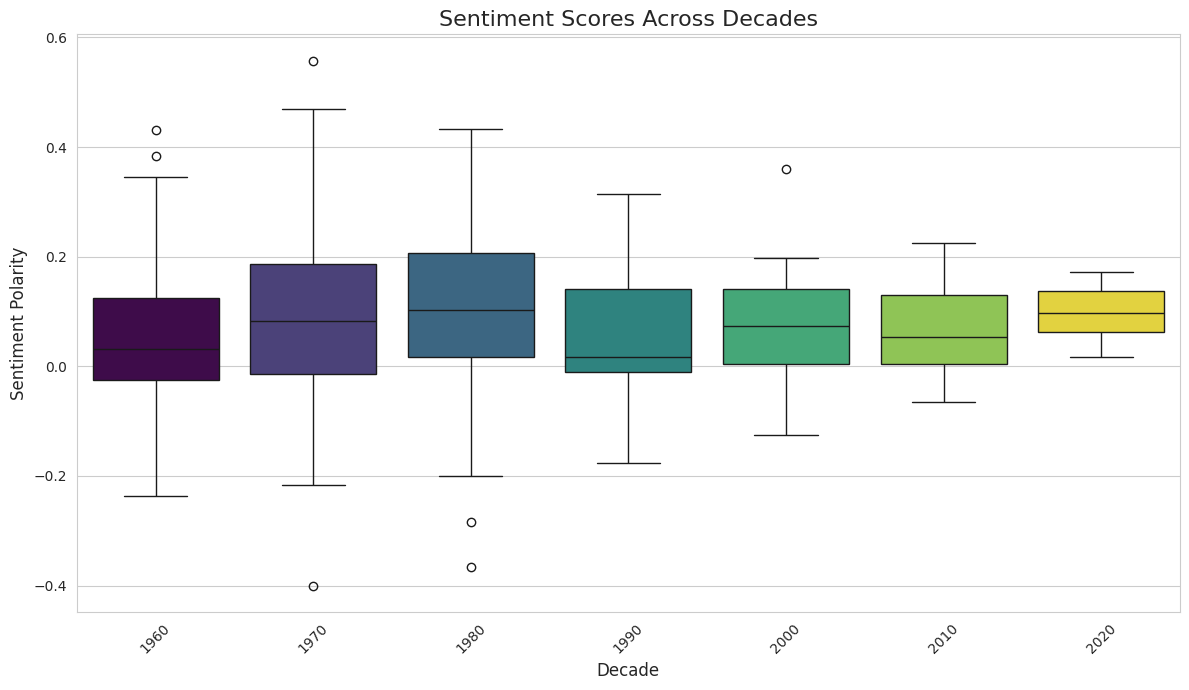

In [29]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Recalculate 'decade' to ensure it's available in case of kernel reset
df['decade'] = (df['release_year'] // 10) * 10

# Calculate sentiment polarity for each song
df['sentiment_polarity'] = df['lyrics'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Create the boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis', hue='decade', legend=False)
plt.title('Sentiment Scores Across Decades', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [31]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_KEY')
print(f"API Key: {NEWS_API_KEY}")

API Key: 67ff54cc20b54f92a9e91df005cd09fa


In [32]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-24 to 2026-05-27


In [33]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: Trump
Searching for articles related to: Trump
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 99
Total results matching query (available from API): 3767


,title,author,source,description,date
0,"27,224 people pre-ordered the Trump Phone",Rob Beschizza,Boing Boing,Sz´The Trump Phone was supposed to be made in ...,2026-05-26T16:12:42Z
1,Trump Says He Told Negotiators 'Not to Rush In...,NBC,Yahoo Entertainment,The Trump administration and Iran both say pro...,2026-05-25T11:21:37Z
2,Trump DOJ mass-deletes info on Jan. 6 riot cas...,Tom Dreisbach,NPR,The Trump Department of Justice purged governm...,2026-05-26T18:34:29Z
3,Morning news brief,Steve Inskeep,NPR,Trump touts breakthrough in negotiations to en...,2026-05-25T08:42:16Z
4,"U.S.-Iran peace deal emerging, while war threa...",Jane Arraf,NPR,President Trump and other administration offic...,2026-05-25T10:16:45Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

### Word Analysis - Most Frequent Words in News Article Descriptions ###
Top 20 Most Frequent Words:
  trump: 46
  president: 28
  donald: 17
  iran: 11
  end: 10
  administration: 9
  war: 9
  tuesday: 8
  deal: 7
  house: 7
  medical: 7
  white: 7
  fund: 6
  news: 6
  reuters: 6
  26: 5
  anti: 5
  billion: 5
  court: 5
  military: 5


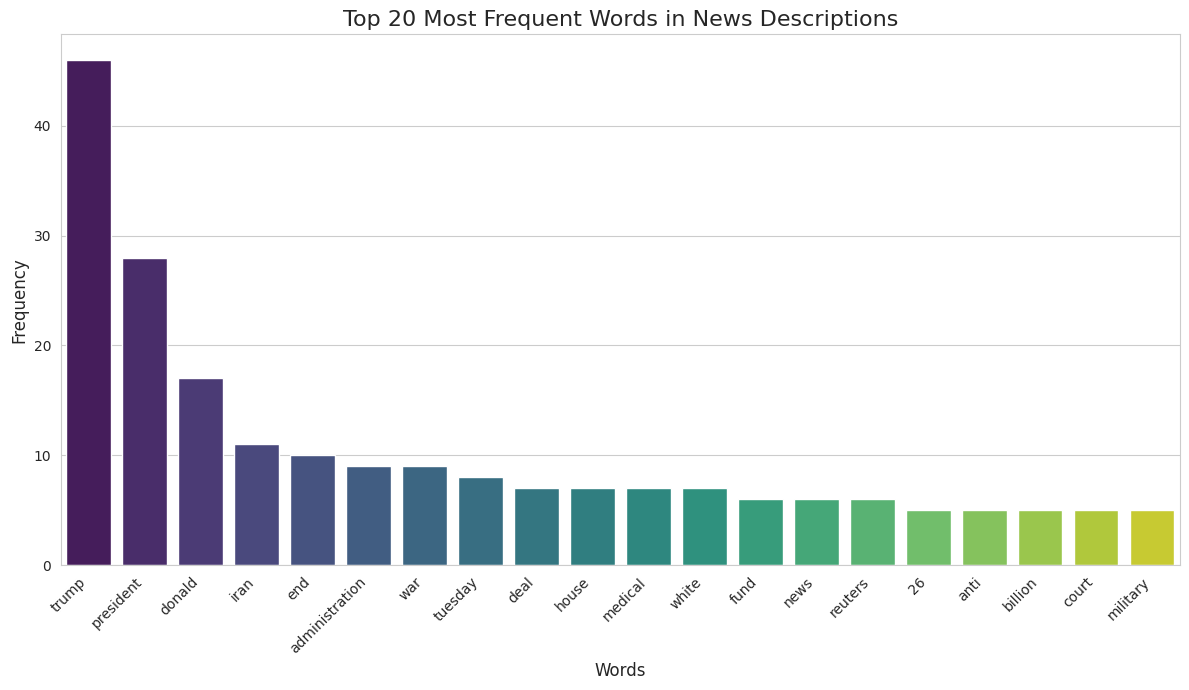


### Sentiment Analysis of News Article Descriptions ###
Sentiment Polarity Statistics for News Article Descriptions:
count    99.000000
mean      0.049590
std       0.222003
min      -1.000000
25%       0.000000
50%       0.000000
75%       0.067424
max       0.800000
Name: sentiment_polarity, dtype: float64


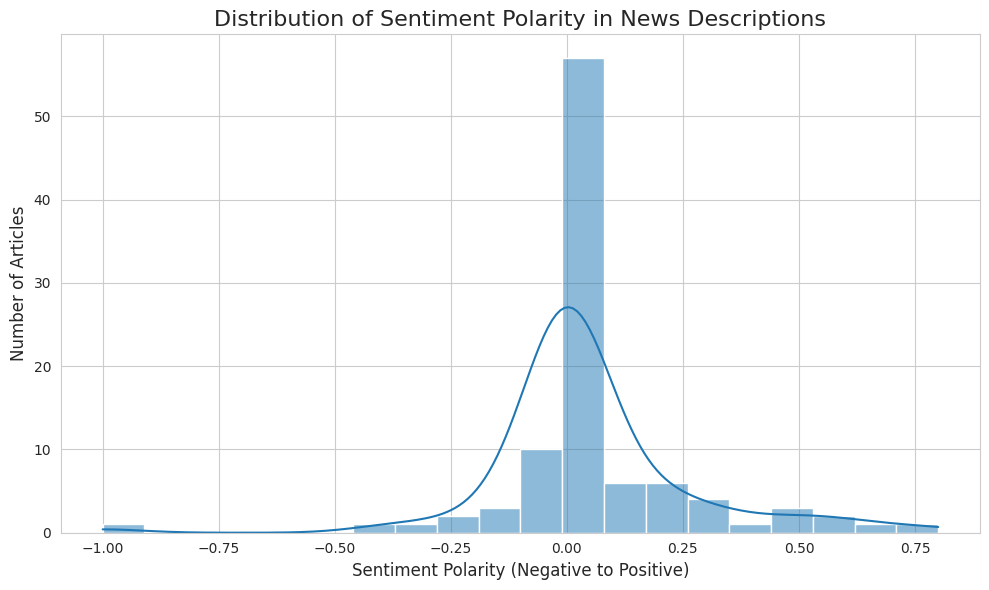


Top 5 Most Positive Articles:
  Title: Sorry, Apple: Samsung’s Fainting Detection Is a Game Changer
  Sentiment: 0.80
  Description: I might just have to consign my Apple Watch to the great tech junkyard in the sky....
--------------------------------------------------
  Title: Trump awards Presidential Medal of Freedom to man who rescued people on 9/11
  Sentiment: 0.70
  Description: Welles Crowther, who died on 9/11, was honored by President Trump for his heroic efforts on Friday. ...
--------------------------------------------------
  Title: TRUMP HEALTH MYSTERY
  Sentiment: 0.60
  Description: Donald Trump built his 2024 campaign on questions about Joe Biden's health. Now, as he approaches hi...
--------------------------------------------------
  Title: South Carolina Senators Just Handed Rep. Jim Clyburn a Stay of Execution, Defying Trump
  Sentiment: 0.60
  Description: 17-term Congressman Jim Clyburn had been in danger of having his district effectively eliminated, bu...
---

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Word Analysis - Most Frequent Words in News Article Descriptions ###")

# Combine all non-null descriptions into a single string for word analysis
# Fill any NaN values with an empty string before joining
all_descriptions_text = " ".join(news_df['description'].fillna(''))

# Initialize CountVectorizer to remove common English stop words
vectorizer = CountVectorizer(stop_words='english')

if all_descriptions_text.strip(): # Check if there's any text to process
    X_news = vectorizer.fit_transform([all_descriptions_text])

    # Sum up the counts of each word (only one document per overall corpus)
    word_counts_news = np.sum(X_news.toarray(), axis=0)

    # Get feature names (words)
    feature_words_news = vectorizer.get_feature_names_out()

    # Combine counts and words into a dictionary
    word_count_dict_news = {word: int(count) for word, count in zip(feature_words_news, word_counts_news)}

    # Sort the dictionary by counts in descending order
    sorted_word_count_news = sorted(word_count_dict_news.items(), key=lambda x: x[1], reverse=True)

    # Print the top 20 most frequent words
    top_n_words_news = 20
    print(f"Top {top_n_words_news} Most Frequent Words:")
    for word, count in sorted_word_count_news[:top_n_words_news]:
        print(f"  {word}: {count}")

    # Optional: Plot the most frequent words
    words_plot = [item[0] for item in sorted_word_count_news[:top_n_words_news]]
    counts_plot = [item[1] for item in sorted_word_count_news[:top_n_words_news]]
    most_frequent_news_df = pd.DataFrame({'Word': words_plot, 'Count': counts_plot})

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Word', y='Count', data=most_frequent_news_df, palette='viridis', hue='Word', legend=False)
    plt.title(f'Top {top_n_words_news} Most Frequent Words in News Descriptions', fontsize=16)
    plt.xlabel('Words', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No descriptions available to analyze words.")


print("\n### Sentiment Analysis of News Article Descriptions ###")

# Calculate sentiment polarity for each article description
# Fill NaN values with empty strings to prevent errors with TextBlob
news_df['sentiment_polarity'] = news_df['description'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)

# Display basic sentiment statistics
print("Sentiment Polarity Statistics for News Article Descriptions:")
print(news_df['sentiment_polarity'].describe())

# Plot a histogram of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(news_df['sentiment_polarity'], bins=20, kde=True)
plt.title('Distribution of Sentiment Polarity in News Descriptions', fontsize=16)
plt.xlabel('Sentiment Polarity (Negative to Positive)', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Display articles with most positive/negative sentiment
print("\nTop 5 Most Positive Articles:")
positive_articles = news_df.sort_values(by='sentiment_polarity', ascending=False).head(5)
for index, row in positive_articles.iterrows():
    print(f"  Title: {row['title']}")
    print(f"  Sentiment: {row['sentiment_polarity']:.2f}")
    print(f"  Description: {row['description'][:100]}...") # Truncate description
    print("-" * 50)

print("\nTop 5 Most Negative Articles:")
negative_articles = news_df.sort_values(by='sentiment_polarity', ascending=True).head(5)
for index, row in negative_articles.iterrows():
    print(f"  Title: {row['title']}")
    print(f"  Sentiment: {row['sentiment_polarity']:.2f}")
    print(f"  Description: {row['description'][:100]}...") # Truncate description
    print("-" * 50)


Word Analysis - Most Frequent Words in News Article Descriptions
As you can see from the list below and the generated bar plot, the most frequent words in the news article descriptions related to 'Trump' are:

trump: 46
president: 28
donald: 17
iran: 11
end: 10
administration: 9
war: 9
tuesday: 8
deal: 7
house: 7
medical: 7
white: 7
fund: 6
news: 6
reuters: 6
26: 5
anti: 5
billion: 5
court: 5
military: 5
These words clearly indicate a focus on political news, particularly concerning Trump's presidency, international relations (Iran), and related political events.

Sentiment Analysis of News Article Descriptions
The sentiment polarity for the news article descriptions has a mean of approximately 0.05, suggesting a slightly positive overall sentiment, but with a wide range from -1.0 (very negative) to 0.8 (very positive). This indicates a diverse mix of positive, negative, and neutral reporting.

Here are some examples of articles with the most positive and negative sentiments:

Top 5 Most Positive Articles:

Title: Sorry, Apple: Samsung’s Fainting Detection Is a Game Changer Sentiment: 0.80
Title: Trump awards Presidential Medal of Freedom to man who rescued people on 9/11 Sentiment: 0.70
Title: TRUMP HEALTH MYSTERY Sentiment: 0.60
Title: South Carolina Senators Just Handed Rep. Jim Clyburn a Stay of Execution, Defying Trump Sentiment: 0.60
Title: When Iran thumbs its nose at the ceasefire, the Trump administration shrugs Sentiment: 0.50
Top 5 Most Negative Articles:

Title: WATCH: College athlete's wisdom tooth surgery led to leukemia diagnosis Sentiment: -1.00
Title: WATCH: Baby elephant charges tourists Sentiment: -0.40
Title: Trump claims 2020 election 'rigged' at least 107 times in six months as midterms loom Sentiment: -0.35
Title: NPR Flubs Its Recovery From Brutal Republican Funding Attacks Sentiment: -0.26
Title: Iran condemns US strikes as a show of 'bad faith' and warns of consequences Sentiment: -0.23
The full distribution of sentiment scores is shown in the generated histogram.

In [35]:
query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: Book
Searching for articles related to: Book
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 99
Total results matching query (available from API): 1699


,title,author,source,description,date
0,Govee included a book on ‘White Supremacy’ in ...,Jess Weatherbed,The Verge,Companies often include background props in th...,2026-05-26T15:07:40Z
1,Briefly Noted Book Reviews,The New Yorker,The New Yorker,"“John of John,” by Douglas Stuart; “Body Doubl...",2026-05-25T10:00:00Z
2,I Never Liked a Laptop Sleeve Until I Tried th...,Luke Larsen,Wired,The Bellroy Laptop Caddy is actually so much m...,2026-05-26T09:32:00Z
3,Why did Kouri Richins want her husband dead?,Emma Steele,CBS News,Kouri Richins published a children's book to h...,2026-05-24T06:10:03Z
4,"WATCH: Martha Raddatz discusses new book, ‘The...",ABC News,Abcnews.com,"Martha Raddatz, ABC News’ chief global affairs...",2026-05-26T13:44:25Z


### Word Analysis - Most Frequent Words in News Article Descriptions (Books) ###
Top 20 Most Frequent Words:
  book: 26
  new: 12
  best: 9
  world: 8
  ai: 7
  books: 7
  project: 7
  author: 6
  good: 6
  history: 6
  like: 5
  tv: 5
  andy: 4
  finally: 4
  laptop: 4
  make: 4
  movies: 4
  ones: 4
  photographer: 4
  post: 4


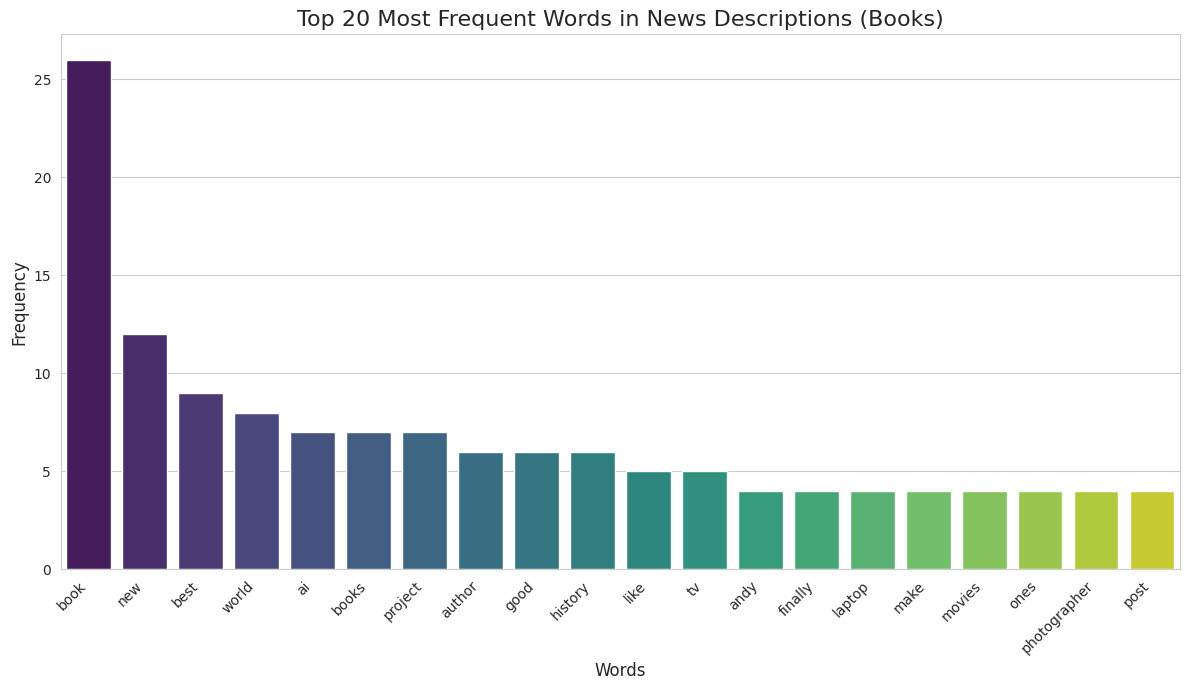


### Sentiment Analysis of News Article Descriptions (Books) ###
Sentiment Polarity Statistics for News Article Descriptions (Books):
count    99.000000
mean      0.171790
std       0.276784
min      -0.500000
25%       0.000000
50%       0.106250
75%       0.315625
max       1.000000
Name: sentiment_polarity_books, dtype: float64


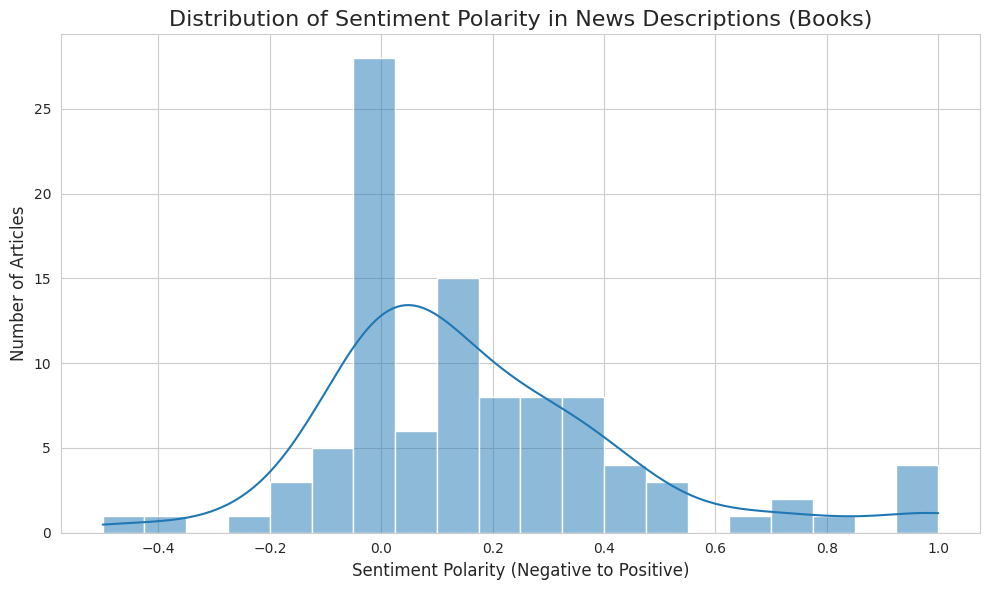


Top 5 Most Positive Articles (Books):
  Title: I've Tested Dozens of Packing Cubes. Here's What's Worth Taking on Your Next Trip
  Sentiment: 1.00
  Description: Whether you’re a no-frills backpacker or a bag-checking fashionista, there’s a perfect packing cube ...
--------------------------------------------------
  Title: I tried all the jarred pasta sauces I could find at Trader Joe's and ranked them from worst to best
  Sentiment: 1.00
  Description: I tried all the Trader Joe's jarred pasta sauces I could find. From organic marinara to cacio e pepe...
--------------------------------------------------
  Title: Hugh Ryan’s Book Notes music book for his book My Bad
  Sentiment: 1.00
  Description: "Receiving a mixtape was the highest honor; making one, the greatest responsibility."...
--------------------------------------------------
  Title: Complete guide to the World of Hyatt loyalty program
  Sentiment: 1.00
  Description: Learn how the World of Hyatt loyalty program works, in

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Word Analysis - Most Frequent Words in News Article Descriptions (Books) ###")

# Combine all non-null descriptions into a single string for word analysis
# Fill any NaN values with an empty string before joining
all_descriptions_text_books = " ".join(news_df['description'].fillna(''))

# Initialize CountVectorizer to remove common English stop words
vectorizer_books = CountVectorizer(stop_words='english')

if all_descriptions_text_books.strip(): # Check if there's any text to process
    X_books = vectorizer_books.fit_transform([all_descriptions_text_books])

    # Sum up the counts of each word (only one document per overall corpus)
    word_counts_books = np.sum(X_books.toarray(), axis=0)

    # Get feature names (words)
    feature_words_books = vectorizer_books.get_feature_names_out()

    # Combine counts and words into a dictionary
    word_count_dict_books = {word: int(count) for word, count in zip(feature_words_books, word_counts_books)}

    # Sort the dictionary by counts in descending order
    sorted_word_count_books = sorted(word_count_dict_books.items(), key=lambda x: x[1], reverse=True)

    # Print the top 20 most frequent words
    top_n_words_books = 20
    print(f"Top {top_n_words_books} Most Frequent Words:")
    for word, count in sorted_word_count_books[:top_n_words_books]:
        print(f"  {word}: {count}")

    # Plot the most frequent words
    words_plot_books = [item[0] for item in sorted_word_count_books[:top_n_words_books]]
    counts_plot_books = [item[1] for item in sorted_word_count_books[:top_n_words_books]]
    most_frequent_news_df_books = pd.DataFrame({'Word': words_plot_books, 'Count': counts_plot_books})

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Word', y='Count', data=most_frequent_news_df_books, palette='viridis', hue='Word', legend=False)
    plt.title(f'Top {top_n_words_books} Most Frequent Words in News Descriptions (Books)', fontsize=16)
    plt.xlabel('Words', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No descriptions available to analyze words for books.")


print("\n### Sentiment Analysis of News Article Descriptions (Books) ###")

# Calculate sentiment polarity for each article description
# Fill NaN values with empty strings to prevent errors with TextBlob
news_df['sentiment_polarity_books'] = news_df['description'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)

# Display basic sentiment statistics
print("Sentiment Polarity Statistics for News Article Descriptions (Books):")
print(news_df['sentiment_polarity_books'].describe())

# Plot a histogram of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(news_df['sentiment_polarity_books'], bins=20, kde=True)
plt.title('Distribution of Sentiment Polarity in News Descriptions (Books)', fontsize=16)
plt.xlabel('Sentiment Polarity (Negative to Positive)', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Display articles with most positive/negative sentiment
print("\nTop 5 Most Positive Articles (Books):")
positive_articles_books = news_df.sort_values(by='sentiment_polarity_books', ascending=False).head(5)
for index, row in positive_articles_books.iterrows():
    print(f"  Title: {row['title']}")
    print(f"  Sentiment: {row['sentiment_polarity_books']:.2f}")
    print(f"  Description: {row['description'][:100]}...") # Truncate description
    print("-" * 50)

print("\nTop 5 Most Negative Articles (Books):")
negative_articles_books = news_df.sort_values(by='sentiment_polarity_books', ascending=True).head(5)
for index, row in negative_articles_books.iterrows():
    print(f"  Title: {row['title']}")
    print(f"  Sentiment: {row['sentiment_polarity_books']:.2f}")
    print(f"  Description: {row['description'][:100]}...") # Truncate description
    print("-" * 50)
